## Stokes Flow in Periodic Channel with Robin boundary.

['rx', 'ry', 'drx_norm', 'dry_norm']


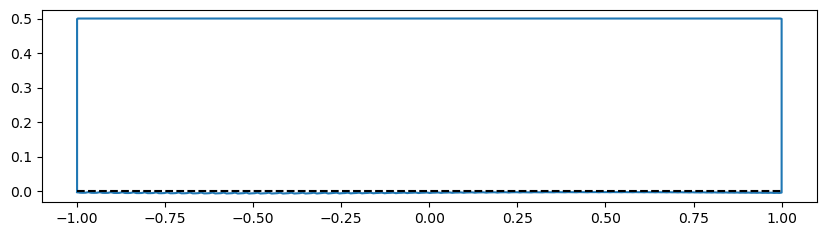

In [49]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "none"#"last_expr_or_assign"

import numpy as np
import matplotlib.pyplot as plt
from util.logger import EventTracker
from util.basis_scaled import *
from util.plot_tools import *
from boundary_solvers.gauss_grid_2d import StokesDirichletProblem
from scipy.io import loadmat
import matplotlib.pyplot as plt
from util.interp import PiecewiseInterp2D
from boundary_solvers.gauss_grid_2d import TrapezGrid
from hmm.stokes import *
from hmm.stokes_deep import DeepMicroSolver, get_net
import matplotlib
from scipy.interpolate import interp1d
from architecture.session import fno_ver3, fno_ver4, fno_ver1, fno_ver2, egeofno_ver2, svdfno_ver2, svdfno_ver1, svdfno_ver3, egeofno_ver5, svdfno_ver4
import torch
from hmm.stokes import StokesData

#matplotlib.rcParams['text.usetex'] = False


#net_dir = "/mnt/data0/emastr/article_training_nodecay/"
net_dir = "/mnt/data0/emastr/training/article_training_lowline/"
MESH_PATH = "/home/emastr/deep-micro-slip-model/data/mesh/"
figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"
simulation_dir = "/home/emastr/deep-micro-slip-model/data/stokes_fenics/"
#data_dir = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_torch/data_big_clean.torch"
run_dir = "/home/emastr/deep-micro-slip-model/data/reference_2/"


eval_pos = 0.0
eps = 0.002#0.005

width= eps*7#5
height= eps*4#3
linePos = 0.0
nMic_clas = 81

xDim = 21
yDim = 21
xDim_reduce = 15
yDim_reduce = 15
n_refine = 2
tol = 1e-10

mac_width = 2
mac_height = 0.5
dom = [[-1, 1], [0.0, mac_height]]

c1, c2 = 1.0, 0.2
k1, k2 = int(1.0/(eps)), int(2.0/(eps))

device = "cpu" # "cuda:0"
num_pts = 256
net = fno_ver4(device=device)
net_data = torch.load(f"{net_dir}fno_vanilla_ver4_seed0_15000.Torch", map_location=torch.device(device))
net.load_state_dict(net_data["state dict"])
net_settings =  {"num_pts": num_pts, \
                 "input_features": net_data["settings"]["input_features"], \
                 "output_features": net_data["settings"]["output_features"],\
                 "device": device, "dtype": torch.float}
print(net_data["settings"]["output_features"])     

def fourier_series(c, k):
    def f(x):
        y = 0*x
        for ci, ki in zip(c, k):
            y = y + ci * np.exp(1j*ki*x)
        return np.real(y)
        
    return f

def get_random_f(eps, num_freq):
    k = 2*np.round(np.random.randint(1, 10, num_freq)/(4*eps))
    c = 0.2*np.random.rand(num_freq)
    
    #k[0] = 4.0
    #c[0] = 0.7
    
    f = fourier_series(eps*c, k)
    df = fourier_series(eps*c * 1j*k, k)
    ddf = fourier_series(-eps*c * k*k, k)
    return f, df, ddf


def random_data():
    f0, df0, ddf0 = get_random_f(eps, 10)
    f_max = max(f0(np.linspace(-1, 1, 1000)))
    f1 = lambda x: f0(x) - f_max*1.0 - eps*1.4


    kA = 4
    c0, c1 = 1.0, 0.4
    b = lambda x: c0+c1*np.sin(kA * x)
    db = lambda x: c1*np.cos(kA * x) * kA
    ddb = lambda x: -c1*np.sin(kA * x) * kA*kA

    f = lambda x: f1(x)*b(x)
    df = lambda x: df0(x)*b(x) + f1(x)*db(x)
    ddf = lambda x: ddf0(x)*b(x) + 2*df0(x)*db(x) + f1(x)*ddb(x)


    g = lambda x: np.ones_like(x)
    return StokesData(f, df, ddf, g, dom, mac_width, mac_height)


def periodic_lerp(x, a, dom):
    # Return function that interpolates the values of a at the points x periodically
    def f(y):
        if np.isscalar(y):
            y = np.array([y])
        out = []
        for yi in y:
            if yi < x[0]:
                x1, x2 = x[0], x[-1]-dom[1]
                a1, a2 = a[0], a[-1]
            elif yi > x[-1]:
                x1, x2 = x[0]+dom[1], x[-1]
                a1, a2 = a[0], a[-1]
            else:
                idx_right = np.searchsorted(x, yi)
                x1 = x[idx_right-1]
                x2 = x[idx_right]
                a1 = a[idx_right-1]
                a2 = a[idx_right]
            out.append(a1 + (a2 - a1) * (yi - x1) / (x2 - x1))
        out = np.array(out)
        if len(y) == 1:
            out = out[0]
        return out
    return f


nMic_deeps = np.array([5, 7, 9, 11, 17, 21, 31, 41, 51])
max_err = np.zeros_like(nMic_deeps).astype(np.float64)


data = random_data()

plt.figure(figsize=(10,2.5))
data.plot(plt.gca(), npts=1000)


In [50]:
np.random.seed(9)

num_reruns = 1
for rerun in range(num_reruns):
    #f0, df, ddf = get_random_f(eps, 10)
    #f_max = max(f0(np.linspace(-1, 1, 1000)))
    #f = lambda x: f0(x) - f_max*1.0 - eps*1.4
    #g = lambda x: np.ones_like(x)
    #data = StokesData(f, df, ddf, g, dom, mac_width, mac_height)
    data = random_data()
    
    macro = StokesMacProb(data, lambda x, a: periodic_lerp(x, a, dom=dom[0]))
    macro_solver = MacroSolver(xDim, yDim, tol=tol)
    sol = macro_solver.solve(macro)
    
    #data_0, _ = StokesData(f, df, ddf, g, dom0, width, height)
    xPos_clas = np.linspace(-1, 1, nMic_clas+1)[:-1]
    micros_clas = [StokesMicProb(data, x, width, height, linePos=linePos, deg_project=8, \
                            n_refine=n_refine, xDim_reduce=xDim_reduce, yDim_reduce=yDim_reduce) for x in xPos_clas]
    micro_solvers_clas = [MicroSolver(m, tol=tol) for m in micros_clas]
    for m in micros_clas:
        m.update(sol)
    macro_data_clas = [solver.solve(m) for m, solver in zip(micros_clas, micro_solvers_clas)]
    macro_alpha_clas = np.array([m.alpha for m in macro_data_clas])

    for n_idx, nMic_deep in enumerate(nMic_deeps):

        xPos_deep = np.linspace(-1, 1, nMic_deep+1)[:-1]
        micros_deep = [StokesMicProb(data, x, width, height, linePos=linePos, deg_project=8, \
                                n_refine=n_refine, xDim_reduce=xDim_reduce, yDim_reduce=yDim_reduce) for x in xPos_deep]
        micro_solvers_deep = [DeepMicroSolver(m, net, net_settings, tol=tol) for m in micros_deep]
            
        #hmm_prob = StokesHMMProblem(macro, micros_deep, data)

        
        for m in micros_deep:
            m.update(sol)
        

        macro_data_deep = [solver.solve(m) for m, solver in zip(micros_deep, micro_solvers_deep)]
        macro_alpha_deep = np.array([m.alpha for m in macro_data_deep])
        interpolated_alpha = periodic_lerp(xPos_deep, macro_alpha_deep, dom[0])(xPos_clas)
        

        max_err[n_idx] += max(np.abs(macro_alpha_clas - interpolated_alpha))
        print(f"nMic_deep: {nMic_deep}, avg_max_err: {max_err[n_idx]/(rerun+1)}, rerun: {rerun}", end="\n")
        
max_err = max_err / num_reruns
    

nMic_deep: 5, avg_max_err: 0.0027474674460592867, rerun: 0
nMic_deep: 7, avg_max_err: 0.0021451576132158786, rerun: 0
nMic_deep: 9, avg_max_err: 0.0020839583920987136, rerun: 0
nMic_deep: 11, avg_max_err: 0.0017657731859017252, rerun: 0
nMic_deep: 17, avg_max_err: 0.0019016192232491082, rerun: 0
nMic_deep: 21, avg_max_err: 0.0017733217900318104, rerun: 0
nMic_deep: 31, avg_max_err: 0.0019640963535930258, rerun: 0
nMic_deep: 41, avg_max_err: 0.0017006734158910807, rerun: 0
nMic_deep: 51, avg_max_err: 0.0022648268521309775, rerun: 0


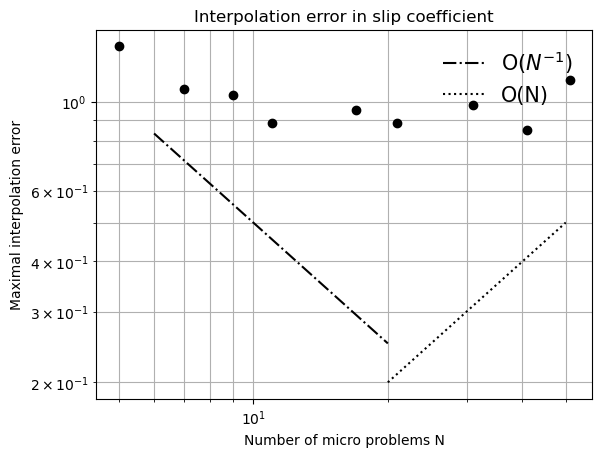

In [51]:
nMic_deeps = np.array(nMic_deeps)
max_err = np.array(max_err)

Ns1 = np.linspace(6, 20, 10)
Ns2 = np.linspace(20, 50, 10)
plt.loglog(nMic_deeps, max_err/eps, 'ko')
plt.plot(Ns1, Ns1**(-1.0)*0.01/eps, 'k-.', label="O($N^{-1}$)")
plt.plot(Ns2, Ns2*0.00002/eps, 'k:', label="O(N)")
plt.legend(frameon=False, loc="upper right", fontsize=15)
plt.xlabel("Number of micro problems N")
plt.ylabel("Maximal interpolation error")
plt.title("Interpolation error in slip coefficient")
plt.grid(which='both')
plt.savefig(f"{figures_dir}interpolation_error2.pdf", dpi=300, bbox_inches='tight')


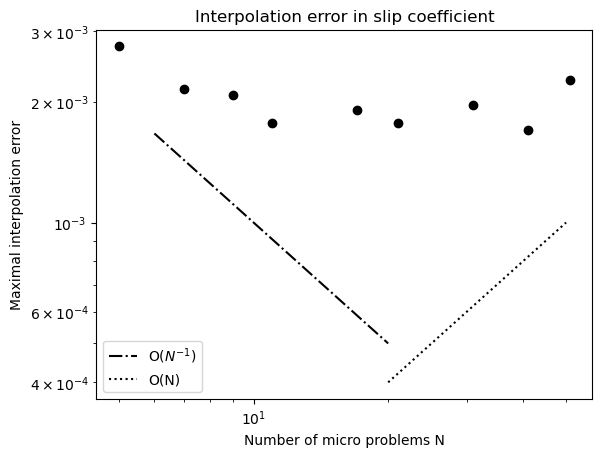

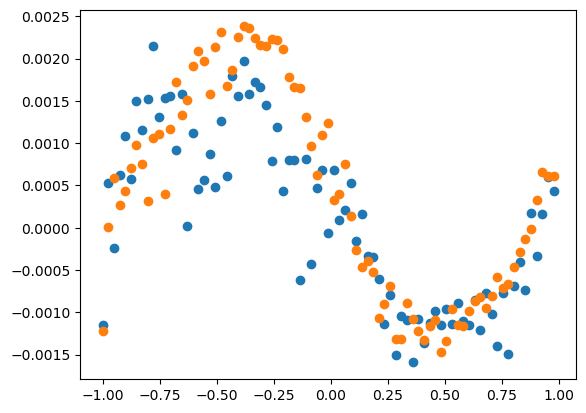

In [52]:
nMic_deeps = np.array(nMic_deeps)
max_err = np.array(max_err)

Ns1 = np.linspace(6, 20, 10)
Ns2 = np.linspace(20, 50, 10)
plt.loglog(nMic_deeps, max_err, 'ko')
plt.plot(Ns1, Ns1**(-1.0)*0.01, 'k-.', label="O($N^{-1}$)")
plt.plot(Ns2, Ns2*0.00002, 'k:', label="O(N)")
plt.legend()
plt.xlabel("Number of micro problems N")
plt.ylabel("Maximal interpolation error")
plt.title("Interpolation error in slip coefficient")
#plt.savefig(f"{figures_dir}interpolation_error.png", dpi=300, bbox_inches='tight')

plt.figure()
plt.plot(xPos_clas, macro_alpha_clas, 'o', label="macro")
plt.plot(xPos_clas, interpolated_alpha, 'o', label="interpolated")


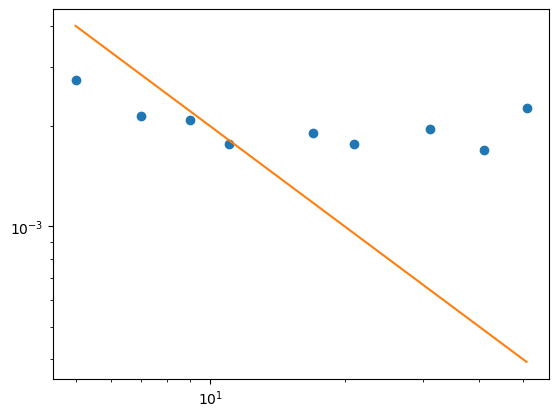

In [53]:
nMic_deeps = np.array(nMic_deeps)
max_err = np.array(max_err)

plt.loglog(nMic_deeps, max_err, 'o')
plt.plot(nMic_deeps, nMic_deeps**(-1.0)*0.02)

NameError: name 'hmm_prob' is not defined

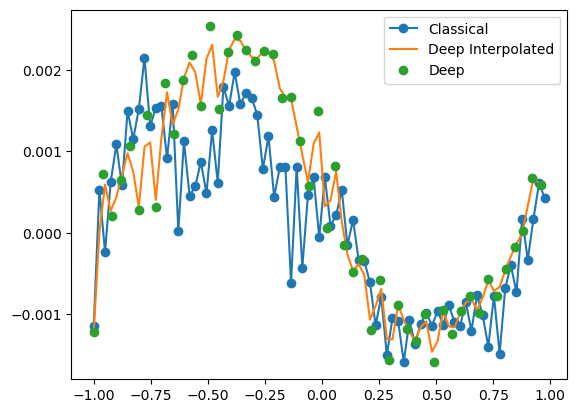

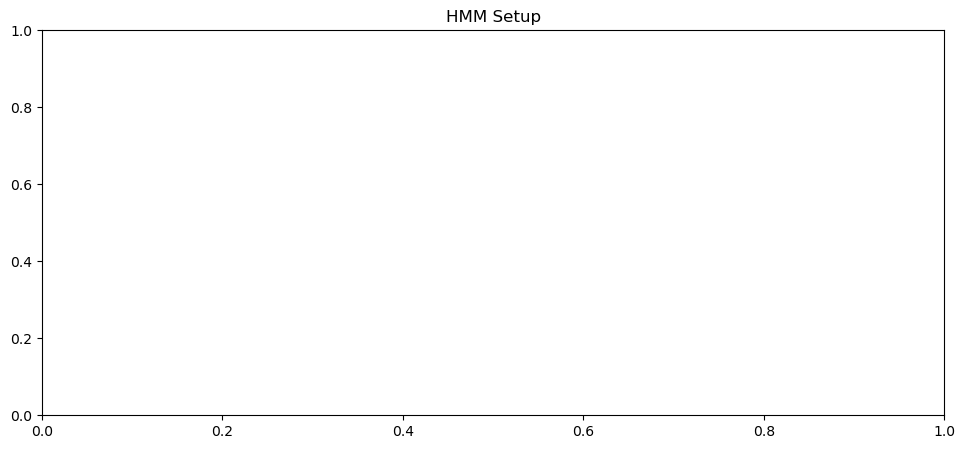

In [54]:


plt.plot(xPos_clas, macro_alpha_clas, "o-", label="Classical")
plt.plot(xPos_clas, interpolated_alpha, "-", label="Deep Interpolated")
plt.plot(xPos_deep, macro_alpha_deep, "o", label="Deep")
plt.legend()

###################
## PLOT ##
plt.figure(figsize=(18,5))

plt.subplot2grid((1, 3), (0, 0), 1, 2)
plt.title("HMM Setup")
hmm_prob.plot(plt.gca())
plt.axis("Equal")
remove_top_right_axes(plt.gca())

plt.subplot2grid((1, 3), (0, 2), 1, 1)
plt.title("Micro Domain 1")
micros_deep[0].plot(plt.gca(), showsegments=True)
plt.axis("equal")
remove_top_right_axes(plt.gca())

### Load Network for evaluation

error in r: 7.63e-02, in dr: 7.05e-02
error in r: 3.81e-02, in dr: 1.51e-01
error in r: 3.39e-02, in dr: 6.03e-02
error in r: 3.03e-02, in dr: 6.96e-02
error in r: 4.20e-02, in dr: 9.37e-02
error in r: 3.42e-02, in dr: 1.56e-01
error in r: 5.29e-02, in dr: 7.46e-02


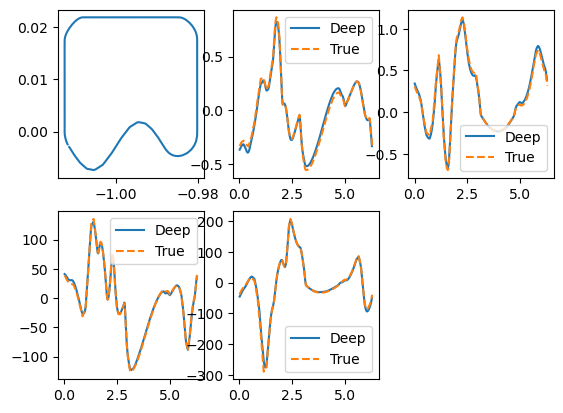

In [ ]:


num_mic = len(micro_solvers)
sqrt_num_mic = int(np.ceil(num_mic**0.5))
for i, (s, self) in enumerate(zip(micro_solvers, deep_micro_solvers)):
    #print(list(ds.__dict__.keys()))
    self.r_true, self.avg_true = self.geom.precompute_line_avg(derivative=0)
    self.dr_true, self.davg_true = self.geom.precompute_line_avg(derivative=1)
    t1, _ = self.geom.grid.get_grid_and_weights()
    r_true_t = interp_periodic(t1, self.r_true, self.t)
    dr_true_t = interp_periodic(t1, self.dr_true, self.t)
    
    #plt.plot(self.t, r_true_t)
    #plt.plot(self.t, self.r)
    
    
    #plt.figure(1, figsize=(7,15))
    
    #plt.subplot(2*sqrt_num_mic, sqrt_num_mic, i+1)
    #plt.plot(self.t, np.abs(r_true_t))
    #plt.plot(self.t, np.abs(self.r), '--')
    #plt.plot(self.t, np.abs(self.r - r_true_t), ':')
    
    #plt.subplot(2*sqrt_num_mic, sqrt_num_mic, sqrt_num_mic**2 + i + 1)
    #plt.plot(self.t, np.abs(dr_true_t))
    #plt.plot(self.t, np.abs(self.dr), '--')
    #plt.plot(self.t, np.abs(self.dr - dr_true_t), ':')
    print(f"error in r: {np.linalg.norm(self.r - r_true_t)/np.linalg.norm(r_true_t):.2e}, " +\
           f"in dr: {np.linalg.norm(self.dr - dr_true_t)/np.linalg.norm(dr_true_t):.2e}")
#plt.plot(ds.dr[::2].imag)
#lt.plot(ds.dr_true.imag)
#deep_micro_solvers[0].plot()  

for i in range(1):#len(micro_solvers)):
    plt.figure()
    deep_micro_solvers[i].plot()

In [ ]:
macro_guess = macro_solver_0.solve(macro_0)

print("Deep HMM Solver...")
(deep_macro_sol, deep_micro_sols) = deep_hmm_solver.solve(hmm_prob, macro_guess=macro_guess, 
                                           callback=debug_cb, verbose=True, maxiter=20, tol=tol, logger=logger)
print("\nDone")

deep_diff = debug_cb.diff
debug_cb.diff = []
debug_cb.micro_errors = []

print("Classic HMM Solver...")
(macro_sol, micro_sols) = hmm_solver.solve(hmm_prob, macro_guess=macro_guess, 
                                           callback=debug_cb, verbose=True, maxiter=20, tol=tol, logger=logger)
print("\nDone")





Deep HMM Solver...
Step 19/20
Done
Classic HMM Solver...
Step 19/20
Done


### Convergence and computation time

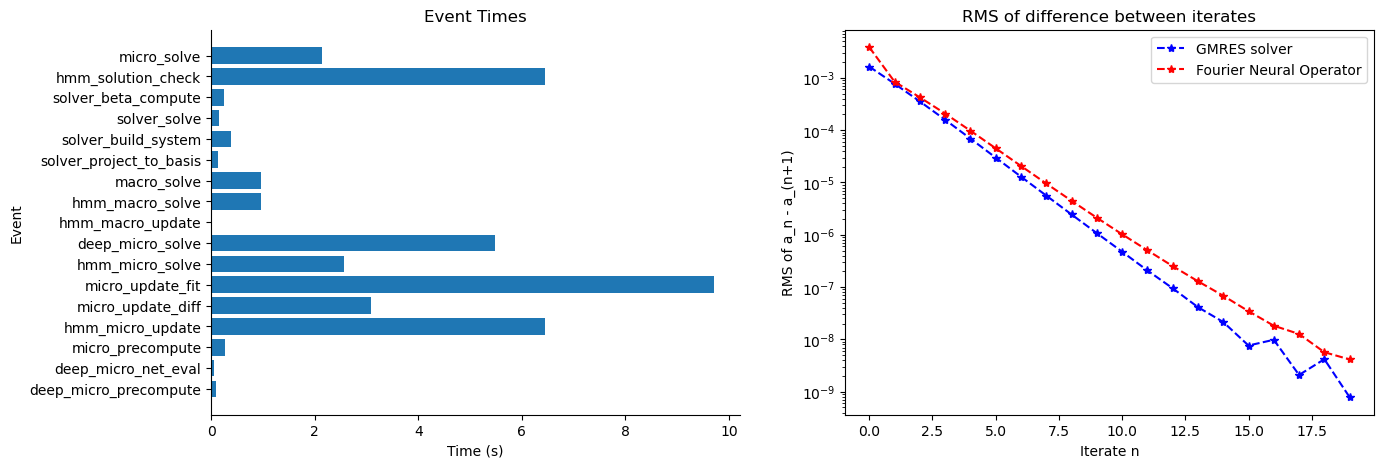

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(122)
plt.title("RMS of difference between iterates")
plt.semilogy(debug_cb.diff, 'b*--', label='GMRES solver')
plt.semilogy(deep_diff, 'r*--', label='Fourier Neural Operator')

plt.legend()
plt.xlabel("Iterate n")
plt.ylabel("RMS of a_n - a_(n+1)")

plt.subplot(121)
logger.barplot_logs(plt.gca())


## Accuracy
We use the reference solver data to construct a piecewise linear interpolation. Also, the micro data is used to construct a set of full solutions to the velocity field in the micro problems for visualisation purposes.

deep: 0.02170
naive: 0.26569
smooth: 0.03807


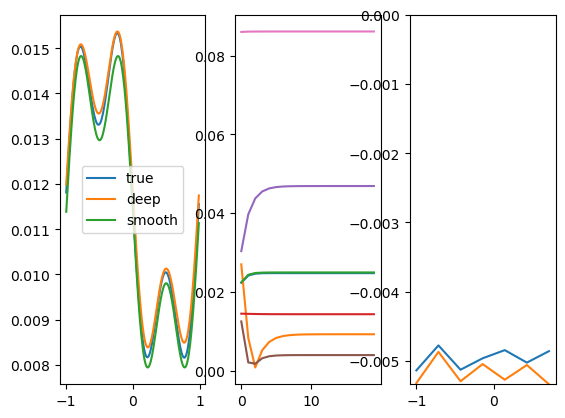

<Figure size 640x480 with 0 Axes>

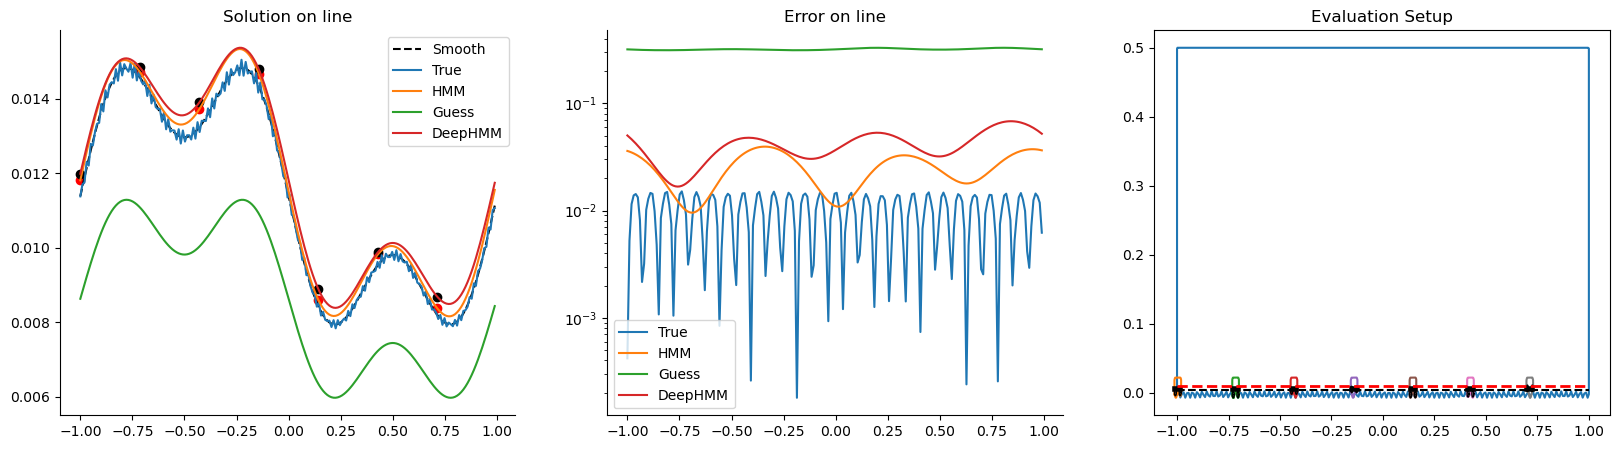

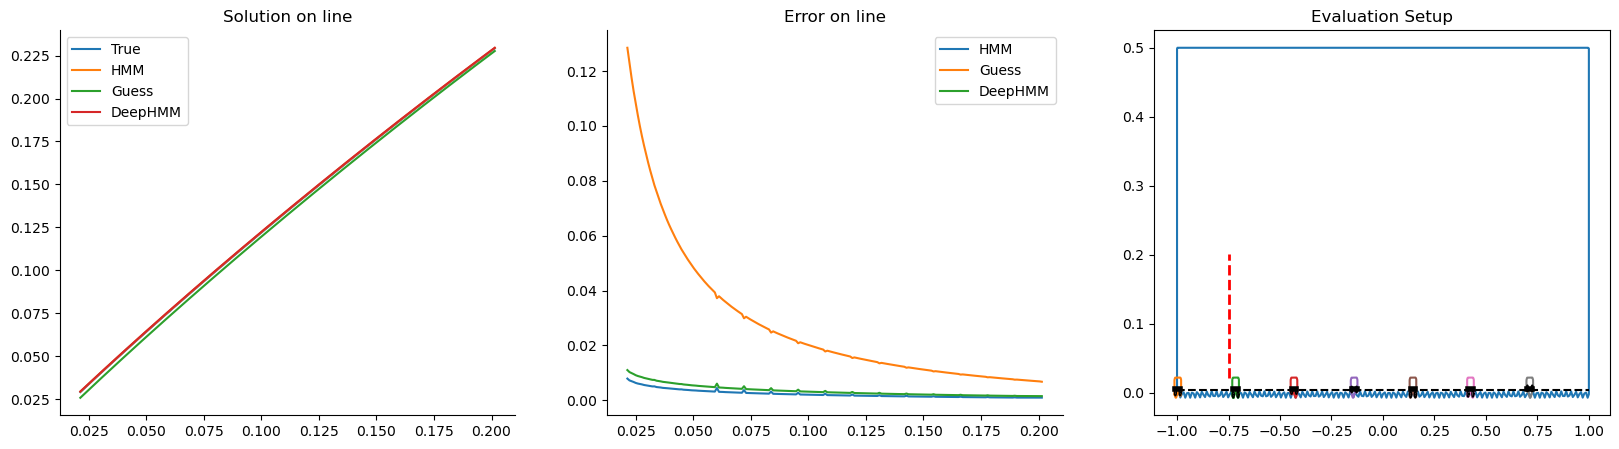

In [ ]:
macro_guess = macro_solver.solve(macro_0)


def error(x, y):
    #return np.linalg.norm(x - y) / np.linalg.norm(x)
    return np.max(np.abs(x-y))/np.max(np.abs(x))

# plot a line at y = 0.03
xval = np.linspace(dom[0][0],dom[0][1], 200)[:-1]
yval = np.ones_like(xval)*0.01
basis = ScaleShiftedBasis.fromFunctionInDomain(lambda x: pwlerp(x,yval), dom[0], FourBasis, dim=len(yval)).change_dim(nMic*2+1)
smooth = lambda x, y: basis(x)
funcs = [smooth, pwlerp, macro_sol.u, macro_guess.u, deep_macro_sol.u]
title = ["Smooth", "True", "HMM", "Guess", "DeepHMM"]

plt.figure()
plt.subplot(131)
plt.plot(xval, macro_sol.u(xval, yval), label='true')
plt.plot(xval, deep_macro_sol.u(xval, yval), label="deep")
plt.plot(xval, smooth(xval, yval), label="smooth")
plt.legend()

plt.subplot(132)
for i in range(len(micros)):
    plt.plot([debug_cb.micro_errors[j][i] for j in range(len(debug_cb.micro_errors))])
    
plt.subplot(133)
plt.plot([m.x for m in micro_sols], [m.alpha for m in micro_sols])
plt.plot([m.x for m in micro_sols], [m.alpha for m in deep_micro_sols])
plt.ylim([min(m.alpha for m in deep_micro_sols), 0])

print(f"deep: {error(macro_sol.u(xval, yval), deep_macro_sol.u(xval, yval)):.5f}")
print(f"naive: {error(macro_sol.u(xval, yval), macro_guess.u(xval, yval)):.5f}")
print(f"smooth: {error(macro_sol.u(xval, yval), smooth(xval, yval)):.5f}")

# Plot solutions on horizontal line

plt.figure()
plot_line(xval, yval, funcs, title, hmm_prob.plot, axis='x')
plt.subplot(1,3,2)
plt.yscale("log")

plt.subplot(1,3,1)
plt.scatter(xPos+width/2, macro_sol.u(xPos+width/2, yval[0]*np.ones_like(xPos)), color='r')
plt.scatter(xPos+width/2, deep_macro_sol.u(xPos+width/2, yval[0]*np.ones_like(xPos)), color='k')

# plot a vertical line in between the first and second micro problems
funcs.pop(0)
title.pop(0)
yval = np.linspace(dom[1][0]+0.02, dom[1][0] + 0.2, 200)
xval = -0.75*np.ones_like(yval) #0.5*(xPos[nMic//2] + xPos[nMic//2+1]) * np.ones_like(yval)

idx = np.arange(len(xval))
s = 13
r = 9

plot_line(xval[idx % s != r], yval[idx % s != r], funcs, title, hmm_prob.plot, axis='y')
#plot_line(xval, yval, funcs, title, hmm_prob.plot, axis='y')

## Visualisation - 2D plots

/tmp/ipykernel_1331708/3928450057.py:24: RuntimeWarning: invalid value encountered in divide
  return np.where(np.abs(omega)<1e-3, np.ones_like(omega), np.sin(omega * a) / (omega * a))


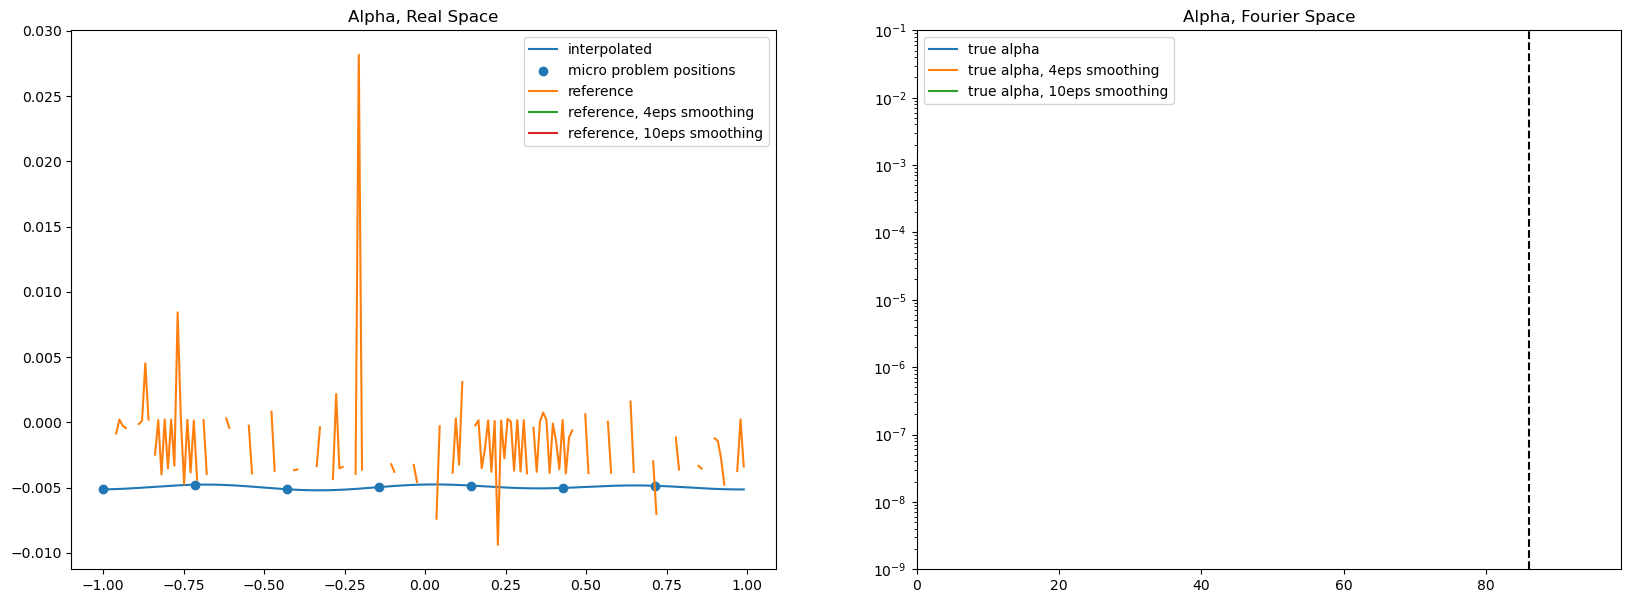

In [ ]:
pwlerp_alpha = lambda x: -pwlerp(x, np.ones_like(x)*eval_pos) / pwlerp_dy(x, np.ones_like(x)*eval_pos)
pwlerp_alpha_2 = lambda x: -pwlerp(x, np.ones_like(x)*0.05) / pwlerp_dy(x, np.ones_like(x)*0.05)


x = np.linspace(dom[0][0],dom[0][1],200)[:-1]
a = macro.alpha(x)
xm = np.array([sol.x for sol in micro_sols])
am = np.array([sol.alpha for sol in micro_sols])

# Estimating alpha
dy = 0.01
y = 0.045*np.ones_like(x)
#a_apx = eval_pos/0.045/10*(pwlerp(x, y+dy)-pwlerp(x, y))/(pwlerp(x, y))-0.01
#_apx = np.sin(x * np.pi * 2)

a_apx = pwlerp_alpha(x)

basis = FourBasis(FourBasis._interpolate(pwlerp_alpha(x)))
freq = np.imag(basis._freq(basis.dim))
ks = freq / (2 * np.pi)
coef = basis.get_coef()

def sq_filt(omega, a):
    return np.where(np.abs(omega)<1e-3, np.ones_like(omega), np.sin(omega * a) / (omega * a))
filt = lambda a: sq_filt(freq, a)
filtered1 = filt(4*eps) * coef
filtered2 = filt(10*eps) * coef

scale, shift  = ScaleShiftedBasis._domain_to_scale_shift(FourBasis._domain(), dom[0])
filtered1_inv = ScaleShiftedBasis(FourBasis(filtered1), scale, shift)
filtered2_inv = ScaleShiftedBasis(FourBasis(filtered2), scale, shift)
truncated_inv = filtered1_inv.change_dim(nMic)

plt.figure(figsize=(20,7))

plt.subplot(121)
plt.title("Alpha, Real Space")
plt.plot(x, a, label="interpolated")
plt.scatter(xm, am, label="micro problem positions")
plt.plot(x, a_apx, label="reference")
filtered1_inv.plot(plt.gca(), dim=200, label="reference, 4eps smoothing")
filtered2_inv.plot(plt.gca(), dim=200, label="reference, 10eps smoothing")
plt.legend()

plt.subplot(122)
plt.title("Alpha, Fourier Space")
plt.semilogy(ks, np.abs(coef), label="true alpha")
#plt.semilogy(freq, filt(eps) * coef)
plt.semilogy(ks, np.abs(filtered1), label="true alpha, 4eps smoothing")

plt.semilogy(ks, np.abs(filtered2), label="true alpha, 10eps smoothing")
# plot vertical lines at frequencies corresponding to eps
plt.plot([nper, nper], [1e-9, 1e-1], 'k--')
plt.legend()
plt.ylim([1e-9, 1e-1])
plt.xlim([0, max(ks)])

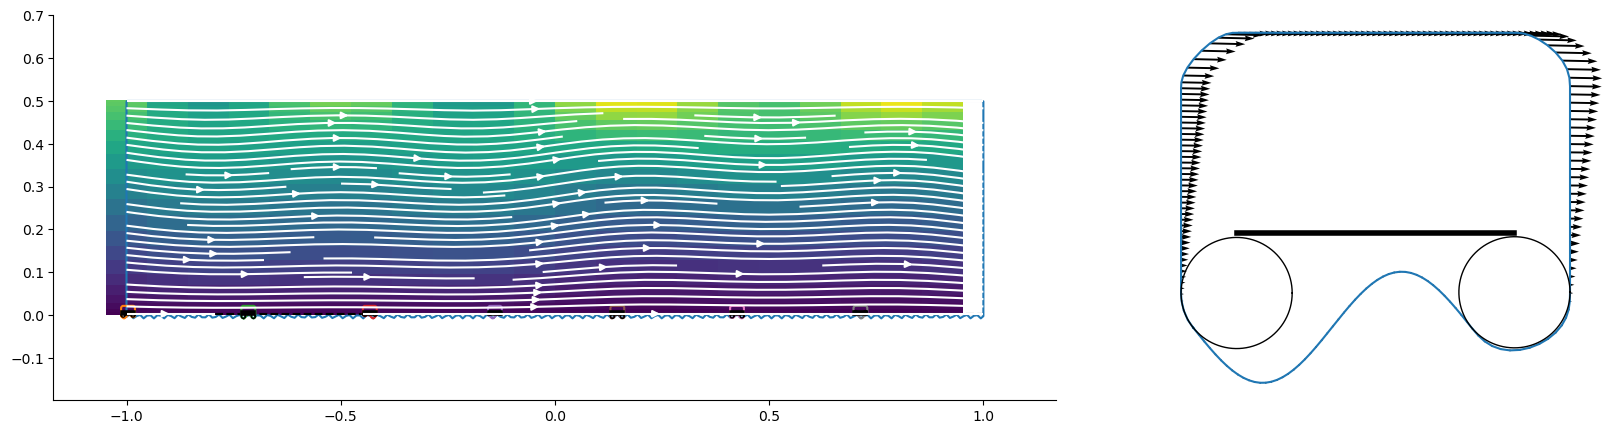

In [ ]:
from util.basis_scaled import ScaleShiftedBasis
plt.figure(figsize=(20,5))

plt.subplot2grid((1, 3), (0, 0), 1, 2)
plt.axis("equal")
hmm_prob.plot(plt.gca())
macro_sol.u.plot(plt.gca())
macro_sol.plot_stream(plt.gca(), color="white")
w = dom[0][1] - dom[0][0]
plt.xlim([dom[0][0]-0.1*w, dom[0][1]+0.1*w])
plt.ylim([dom[1][0]-0.1*w, dom[1][1]+0.1*w])
remove_top_right_axes(plt.gca())

plt.subplot2grid((1, 3), (0, 2), 1, 1)
micros[0].plot(plt.gca())
micros[0].geom.plot_field_on_boundary(plt.gca(), micros[0].condition)
plt.axis("equal")
remove_axes(plt.gca())

/tmp/ipykernel_1331708/4096828511.py:19: RuntimeWarning: invalid value encountered in divide
  return np.where(np.abs(omega)<1e-3, np.ones_like(omega), np.sin(omega * a) / (omega * a))


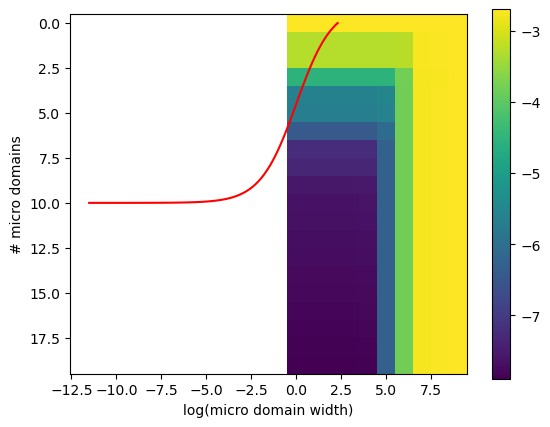

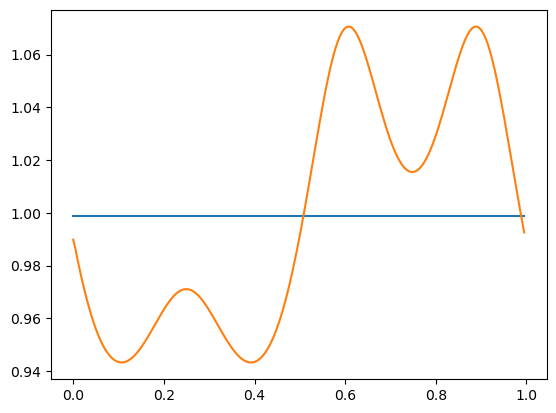

In [ ]:
from util.basis_scaled import ScaleShiftedBasis

x = np.linspace(dom[0][0],dom[0][1],401)
a = macro.alpha(x)
xm = np.array([sol.x for sol in micro_sols])
am = np.array([sol.alpha for sol in micro_sols])

# Estimating alpha
dy = 0.01
y = 0.045*np.ones_like(x)
a_apx = (pwlerp(x, y+dy)-pwlerp(x, y))/pwlerp(x, y)
a_apx = a_apx / np.mean(a_apx**2)**0.5

basis = FourBasis(FourBasis._interpolate(a_apx))
freq = np.imag(basis._freq(basis.dim))
coef = basis.get_coef()

def sq_filt(omega, a):
    return np.where(np.abs(omega)<1e-3, np.ones_like(omega), np.sin(omega * a) / (omega * a))
filt = lambda a: sq_filt(freq, a)

hs = np.logspace(-5, 1, 10)
#hs = np.linspace(0.1, 4, 10)
dims = np.array([2 * m + 1 for m in range(0, 20)])
mse = []
for d in dims:
    mse_sub = []
    for h in hs:
        filtered = filt(h) * coef
        filt_basis = FourBasis(filtered)
        trunc = filt_basis.change_dim(d).change_dim(basis.dim)
        mse_sub.append(np.mean(np.abs((trunc - basis).eval_grid())**2))
        #mse_sub.append(np.mean(np.abs(trunc.coef - basis.coef)**2))
    mse.append(mse_sub)
H, D = np.meshgrid(hs, dims)
logH = np.log(H)
c = 0.001
c2 = 11
hbig = np.logspace(-5, 1, 100)

plt.figure()
#plt.pcolormesh(logH, D, np.log10(np.array(mse))) # + c * H * D
plt.imshow(np.log10(np.array(mse))) # + c * H * D
#plt.plot(np.log(hbig), c2/(hbig+1)-1, 'red')
plt.plot(np.log(hbig), c2/(hbig+1)-1, 'red')
plt.colorbar()
plt.xlabel("log(micro domain width)")
plt.ylabel("# micro domains")

plt.figure()
trunc.plot(plt.gca(), 200)
basis.plot(plt.gca(), 200)

In [ ]:
xhd = np.linspace(dom[0][0],dom[0][1], Nx)
yhd = np.linspace(dom[1][0]-0.1,dom[1][1], Ny)
Xhd, Yhd = np.meshgrid(xhd, yhd)
Uhd = pwlerp(Xhd.flatten(),Yhd.flatten()).reshape((Ny, Nx))

full_micro_sols = []
for it, m in enumerate(micros):
    prob = StokesDirichletProblem(m.geom, m.condition)
    print(f"solving {it}/{len(micros)}", end="\r")
    prob.solve(verbose=False)
    full_micro_sols.append(prob)

NameError: name 'Nx' is not defined

/tmp/ipykernel_37052/2334165283.py:5: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.pcolormesh(Xhd, Yhd, Uhd, vmin=vmin, vmax=vmax)#, vmin=0, vmax=0.003)#, vmin=-0.5, vmax=0.5)#, vmin=-0.5, vmax=0.5)
/home/emastr/phd/util/interp.py:53: RuntimeWarning: divide by zero encountered in true_divide
  return (w1 * z0[0] + w2 * z0[1] + w3 * z0[2] + w4 * z0[3]) / (w1 + w2 + w3 + w4)


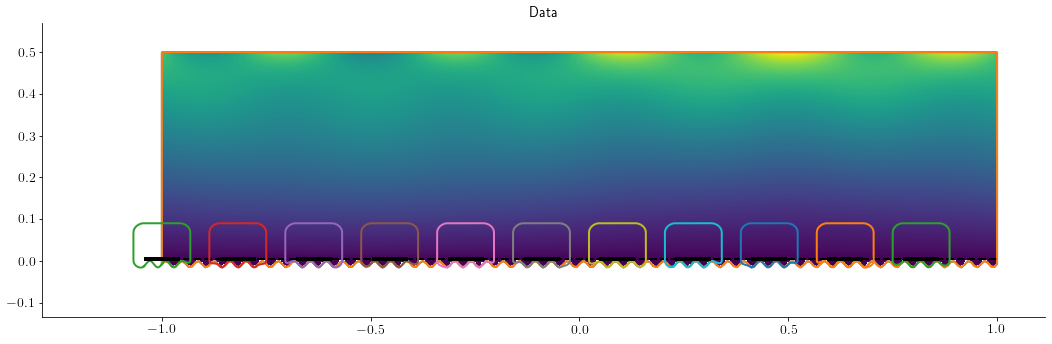

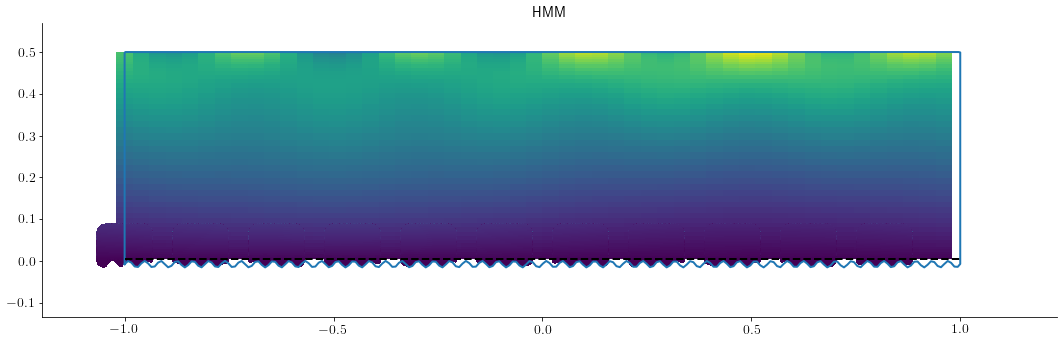

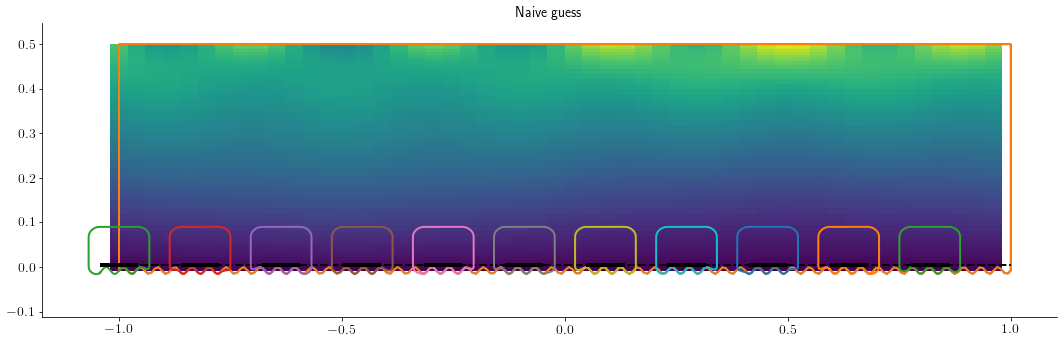

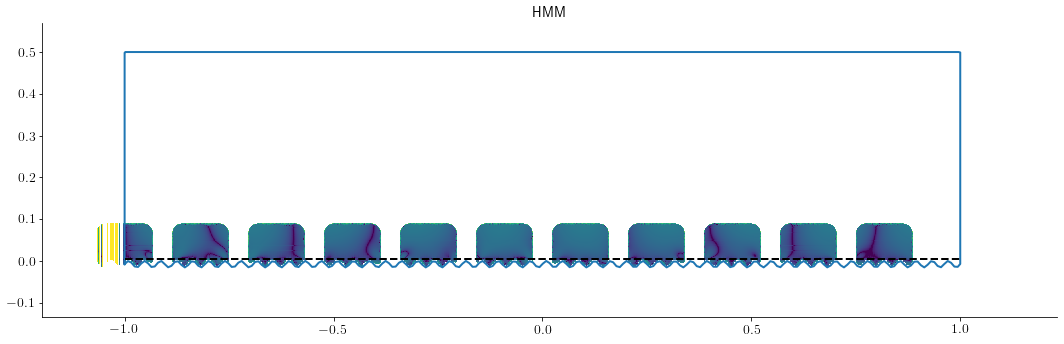

In [ ]:


vmax, vmin = 0.7, 0.

plt.figure(figsize=(15,5))
plt.title("Data")
plt.pcolormesh(Xhd, Yhd, Uhd, vmin=vmin, vmax=vmax)#, vmin=0, vmax=0.003)#, vmin=-0.5, vmax=0.5)#, vmin=-0.5, vmax=0.5)
data.plot(plt.gca())
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.axis("equal")
plt.ylim([dom[1][0]-0.12, dom[1][1]+0.05])
hmm_prob.plot(plt.gca())

plt.figure(figsize=(15,5))
plt.title("HMM")
macro_sol.u.plot(plt.gca(), vmin=vmin, vmax=vmax)
data.plot(plt.gca())
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.axis("equal")
plt.ylim([dom[1][0]-0.12, dom[1][1]+0.05])
for m, s in zip(micros, full_micro_sols):
    m.geom.plot_field(plt.gca(), lambda z: np.real(s.evaluate(z)), apply_mask=True, vmin=vmin, vmax=vmax)
#hmm_prob.plot(plt.gca(), color='black', linewidth=1)



plt.figure(figsize=(15,5))
plt.title("Naive guess")
macro_guess.u.plot(plt.gca(), vmin=vmin, vmax=vmax)
data.plot(plt.gca())
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.axis("equal")
plt.ylim([dom[1][0]-0.12, dom[1][1]+0.05])
hmm_prob.plot(plt.gca(), color='black', linewidth=1)



plt.figure(figsize=(15,5))
plt.title("HMM")
#macro_sol.u.plot(plt.gca(), vmin=vmin, vmax=vmax)
data.plot(plt.gca())
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.axis("equal")
plt.ylim([dom[1][0]-0.12, dom[1][1]+0.05])

ev_u = lambda z: macro_sol.u(np.real(z.flatten()), np.imag(z.flatten())).reshape(z.size)
ev_ut = lambda z: pwlerp(np.real(z.flatten()), np.imag(z.flatten())).reshape(z.size)

for m, s in zip(micros, full_micro_sols):
    #m.geom.plot_field(plt.gca(), lambda z: np.log10(np.abs(np.real(s.evaluate(z))-ev_u(z))), 
                      #apply_mask=True, vmin=-3., vmax=0.)
    m.geom.plot_field(plt.gca(), lambda z: np.log10(np.abs(np.real(s.evaluate(z))-ev_ut(z))), 
                      apply_mask=True, vmin=-5., vmax=0.)
#hmm_prob.plot(plt.gca(), color='black', linewidth=1)


Verifying derivatives